In [1]:
# data exercise to compare OLS and Bayesian Regression
# annual income

In [2]:
!pip install bambi pymc arviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 9.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import bambi as bmb
import pymc as pm
import arviz as az

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson


In [4]:
url = "https://raw.githubusercontent.com/keithmcnulty/peopleanalytics-regression-book/master/data/sociological_data.csv"
socio = pd.read_csv(url)

In [5]:
socio.head()
socio.info()
socio.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2618 entries, 0 to 2617
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   annual_income_ppp  2608 non-null   float64
 1   average_wk_hrs     2584 non-null   float64
 2   education_months   2599 non-null   float64
 3   region             2618 non-null   object 
 4   job_type           2618 non-null   object 
 5   gender             2595 non-null   object 
 6   family_size        2427 non-null   float64
 7   work_distance      2206 non-null   float64
 8   languages          2206 non-null   float64
dtypes: float64(6), object(3)
memory usage: 184.2+ KB


,annual_income_ppp,average_wk_hrs,education_months,family_size,work_distance,languages
count,2608.000000,2584.000000,2599.000000,2427.000000,2206.000000,2206.000000
mean,76040.057132,44.190402,179.317815,3.259580,0.985041,1.018132
std,20981.738753,5.856006,39.693201,1.470578,5.020615,0.205673
min,2863.000000,30.000000,40.000000,0.000000,0.000000,1.000000
25%,62653.000000,39.000000,157.000000,2.000000,0.000000,1.000000
50%,82140.000000,43.000000,184.000000,3.000000,0.000000,1.000000
75%,90112.000000,50.000000,207.000000,4.000000,1.000000,1.000000
max,119564.000000,55.000000,280.000000,10.000000,105.000000,5.000000


In [6]:
socio_encoded = pd.get_dummies(
    socio,
    columns=["region", "job_type", "gender"],
    drop_first=True
)

In [7]:
[s for s in socio_encoded.columns if "job_type" in s]


['job_type_Unskilled']

In [8]:
[s for s in socio_encoded.columns if "region" in s]


['region_Central Asia',
 'region_Eastern Asia',
 'region_Eastern Europe',
 'region_Latin America and the Caribbean',
 'region_Melanesia',
 'region_Micronesia',
 'region_Northern Africa',
 'region_Northern America',
 'region_Northern Europe',
 'region_Polynesia',
 'region_South-eastern Asia',
 'region_Southern Asia',
 'region_Southern Europe',
 'region_Sub-Saharan Africa',
 'region_Western Asia',
 'region_Western Europe']

In [9]:
len([s for s in socio_encoded.columns if "region_" in s])

16

In [10]:
socio_clean = socio_encoded.dropna().copy()

print(socio.shape)
print(socio_clean.shape)

(2618, 9)
(2036, 24)


In [11]:
X = socio_clean.drop(columns=["annual_income_ppp"]).copy()
print(X.dtypes.sort_values())

region_Northern Africa                       bool
region_Western Europe                        bool
region_Western Asia                          bool
region_Sub-Saharan Africa                    bool
region_Southern Europe                       bool
region_Southern Asia                         bool
region_South-eastern Asia                    bool
region_Polynesia                             bool
region_Northern Europe                       bool
region_Northern America                      bool
job_type_Unskilled                           bool
gender_M                                     bool
region_Melanesia                             bool
region_Latin America and the Caribbean       bool
region_Eastern Europe                        bool
region_Eastern Asia                          bool
region_Central Asia                          bool
region_Micronesia                            bool
languages                                 float64
work_distance                             float64


In [12]:
X = X.astype(float)

In [13]:
import statsmodels.api as sm

X = sm.add_constant(X)
y = socio_clean["annual_income_ppp"]

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:      annual_income_ppp   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     358.7
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:57:12   Log-Likelihood:                -21565.
No. Observations:                2036   AIC:                         4.318e+04
Df Residuals:                    2012   BIC:                         4.331e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

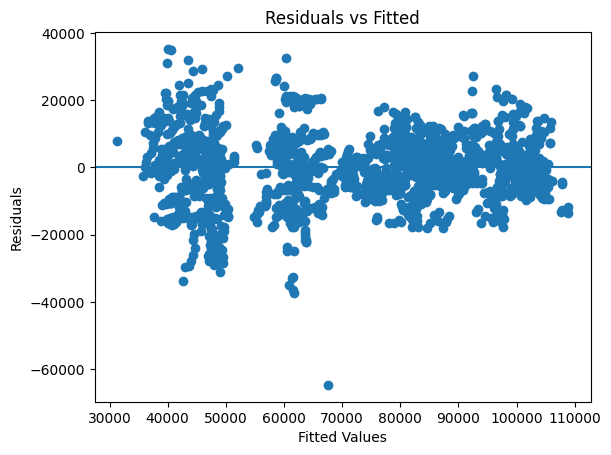

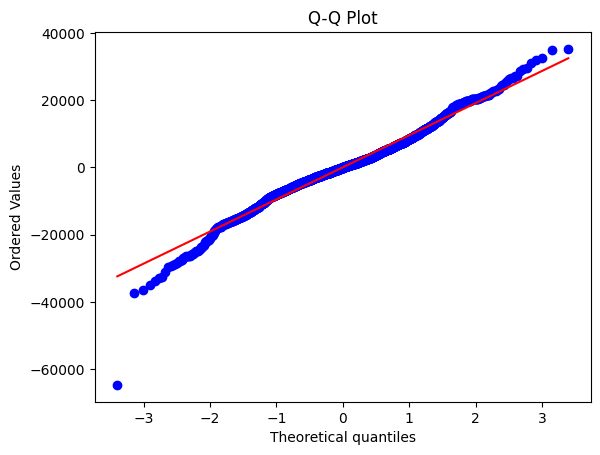

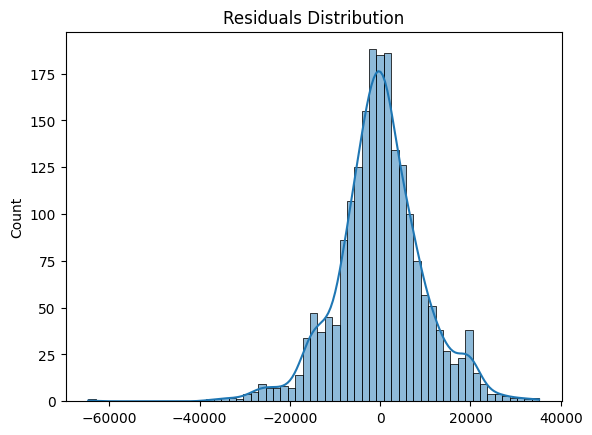

Breusch-Pagan p-value: 7.490896726751548e-52
Durbin-Watson: 0.3568368849276813


In [14]:

# OLS Assumptions

residuals = ols_model.resid
fitted = ols_model.fittedvalues

# 1. Residuals vs Fitted (linearity + homoscedasticity)
plt.figure()
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# 2. Q-Q Plot (normality)
plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

# 3. Histogram (normality)
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

# 4. Breusch-Pagan test (heteroscedasticity)
bp_test = het_breuschpagan(residuals, ols_model.model.exog)
print("Breusch-Pagan p-value:", bp_test[1])

# 5. Durbin-Watson (autocorrelation)
dw = durbin_watson(residuals)
print("Durbin-Watson:", dw)

In [15]:
# correct the model to use robust standard error estimates due to heteroskadasticity

ols_model_robust = ols_model.get_robustcov_results()
print(ols_model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:      annual_income_ppp   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     370.2
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:57:13   Log-Likelihood:                -21565.
No. Observations:                2036   AIC:                         4.318e+04
Df Residuals:                    2012   BIC:                         4.331e+04
Df Model:                          23                                         
Covariance Type:                  HC1                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [16]:
# Bayesian Regression

In [17]:
url = "https://raw.githubusercontent.com/keithmcnulty/peopleanalytics-regression-book/master/data/sociological_data.csv"
socio = pd.read_csv(url)

socio_encoded = pd.get_dummies(
    socio,
    columns=["region", "job_type", "gender"],
    drop_first=True
)

socio_clean = socio_encoded.dropna().copy()
print(socio_clean.shape)
print(socio_clean.dtypes.value_counts())

(2036, 24)
bool       18
float64     6
Name: count, dtype: int64


In [18]:
df_bayes = socio_clean.copy()
df_bayes.columns = [
    c.replace(" ", "_").replace("-", "_").replace("/", "_")
    for c in df_bayes.columns
]

[c for c in df_bayes.columns if "region" in c]

['region_Central_Asia',
 'region_Eastern_Asia',
 'region_Eastern_Europe',
 'region_Latin_America_and_the_Caribbean',
 'region_Melanesia',
 'region_Micronesia',
 'region_Northern_Africa',
 'region_Northern_America',
 'region_Northern_Europe',
 'region_Polynesia',
 'region_South_eastern_Asia',
 'region_Southern_Asia',
 'region_Southern_Europe',
 'region_Sub_Saharan_Africa',
 'region_Western_Asia',
 'region_Western_Europe']

In [19]:
formula = """
annual_income_ppp ~ average_wk_hrs + education_months + family_size +
work_distance + languages + gender_M + job_type_Unskilled +
region_Central_Asia + region_Eastern_Asia + region_Eastern_Europe +
region_Latin_America_and_the_Caribbean + region_Melanesia +
region_Micronesia + region_Northern_Africa + region_Northern_America +
region_Northern_Europe + region_Polynesia + region_South_eastern_Asia +
region_Southern_Asia + region_Southern_Europe + region_Sub_Saharan_Africa +
region_Western_Asia + region_Western_Europe
"""

print(formula)


annual_income_ppp ~ average_wk_hrs + education_months + family_size +
work_distance + languages + gender_M + job_type_Unskilled +
region_Central_Asia + region_Eastern_Asia + region_Eastern_Europe +
region_Latin_America_and_the_Caribbean + region_Melanesia +
region_Micronesia + region_Northern_Africa + region_Northern_America +
region_Northern_Europe + region_Polynesia + region_South_eastern_Asia +
region_Southern_Asia + region_Southern_Europe + region_Sub_Saharan_Africa +
region_Western_Asia + region_Western_Europe



In [20]:
model = bmb.Model(formula, data=df_bayes)
model

       Formula: 
annual_income_ppp ~ average_wk_hrs + education_months + family_size +
work_distance + languages + gender_M + job_type_Unskilled +
region_Central_Asia + region_Eastern_Asia + region_Eastern_Europe +
region_Latin_America_and_the_Caribbean + region_Melanesia +
region_Micronesia + region_Northern_Africa + region_Northern_America +
region_Northern_Europe + region_Polynesia + region_South_eastern_Asia +
region_Southern_Asia + region_Southern_Europe + region_Sub_Saharan_Africa +
region_Western_Asia + region_Western_Europe

        Family: gaussian
          Link: mu = identity
  Observations: 2036
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 74924.4244, sigma: 589720.8241)
            average_wk_hrs ~ Normal(mu: 0.0, sigma: 9356.8312)
            education_months ~ Normal(mu: 0.0, sigma: 1401.4927)
            family_size ~ Normal(mu: 0.0, sigma: 37944.8945)
            work_distance ~ Normal(mu: 0.0, sigma: 10487.6367)
    

In [21]:
idata = model.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=42
)

Output()

In [22]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,59930.823,5369.480,49881.380,69982.140,105.446,58.682,2590.0,3978.0,1.00
average_wk_hrs,-97.894,59.159,-204.348,17.099,0.666,0.698,7914.0,5713.0,1.00
education_months,142.983,10.843,123.081,163.178,0.163,0.113,4440.0,5362.0,1.00
family_size,18.341,174.359,-300.284,361.208,1.883,2.061,8567.0,5563.0,1.00
gender_M,10192.401,793.806,8700.383,11667.449,10.325,8.350,5899.0,5633.0,1.00
job_type_Unskilled,-6129.696,933.822,-7943.510,-4455.759,11.837,10.953,6253.0,5665.0,1.00
languages,-1734.390,2965.941,-7155.849,3948.220,39.713,35.913,5579.0,5036.0,1.00
region_Central_Asia,-11329.402,3079.093,-17047.974,-5735.526,77.600,41.722,1573.0,3020.0,1.00
region_Eastern_Asia,-343.492,3069.390,-6124.428,5337.034,75.007,42.291,1674.0,2924.0,1.00
region_Eastern_Europe,-9042.812,2804.749,-14194.949,-3796.373,69.583,38.708,1625.0,3015.0,1.00


array([[<Axes: title={'center': 'education_months'}>,
        <Axes: title={'center': 'education_months'}>],
       [<Axes: title={'center': 'family_size'}>,
        <Axes: title={'center': 'family_size'}>]], dtype=object)

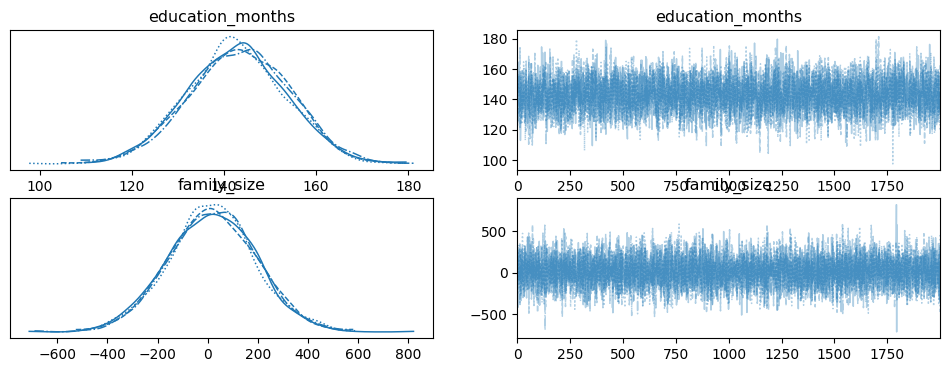

In [23]:
import arviz as az

az.plot_trace(idata, var_names=["education_months", "family_size"])

array([<Axes: title={'center': 'education_months'}>,
       <Axes: title={'center': 'family_size'}>], dtype=object)

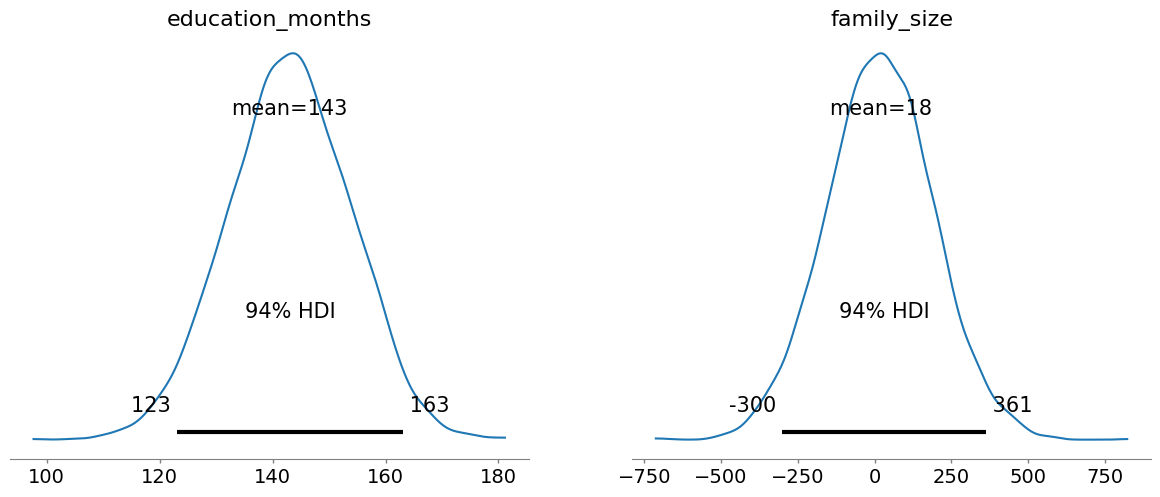

In [24]:
az.plot_posterior(idata, var_names=["education_months", "family_size"])

In [25]:
priors = {
    "family_size": bmb.Prior("Normal", mu=-500, sigma=100),
    "work_distance": bmb.Prior("Normal", mu=0, sigma=100)
}

model_informed = bmb.Model(formula, data=df_bayes, priors=priors)

idata_informed = model_informed.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=4,
    random_seed=42
)

Output()

In [26]:
az.summary(idata, var_names=["family_size", "work_distance"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
family_size,18.341,174.359,-300.284,361.208,1.883,2.061,8567.0,5563.0,1.0
work_distance,-41.277,122.231,-269.532,186.336,1.660,1.466,5425.0,5003.0,1.0


In [30]:
az.summary(idata_informed, var_names=["family_size", "work_distance"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
family_size,-370.267,86.69,-539.510,-211.912,0.963,1.006,8123.0,5602.0,1.0
work_distance,-25.616,77.30,-173.124,115.328,1.056,0.867,5362.0,5297.0,1.0


In [31]:
model.r2_score(idata)

residual_R2(mean=0.8, eti_lb=0.8, eti_ub=0.81)

In [32]:
model_informed.r2_score(idata_informed)

residual_R2(mean=0.8, eti_lb=0.8, eti_ub=0.81)

/usr/local/lib/python3.12/dist-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


<Axes: xlabel='annual_income_ppp'>

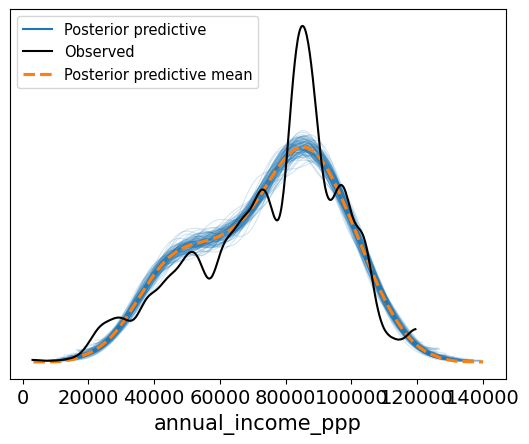

In [33]:
idata_ppc = model_informed.predict(idata_informed, kind="pps", inplace=False)

az.plot_ppc(idata_ppc, num_pp_samples=100)